(np.float64(-11.7373170623862),
 np.float64(7.272829086564677),
 np.float64(-9.970860628000821),
 np.float64(12.743677162116505))

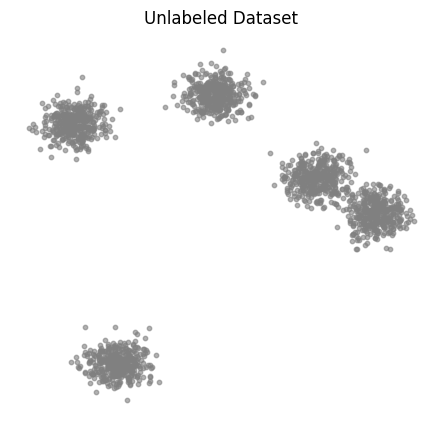

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y_true = make_blobs(n_samples=2000, centers=5, cluster_std=0.7, random_state=42)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c='gray', s=10, alpha=0.6)
plt.title("Unlabeled Dataset")
plt.axis('off')

In [2]:
k = 5
kmeans = KMeans(n_clusters=k)
y_pred = kmeans.fit_predict(X)

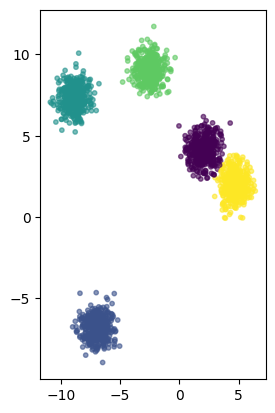

In [3]:
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=10, alpha=0.6)

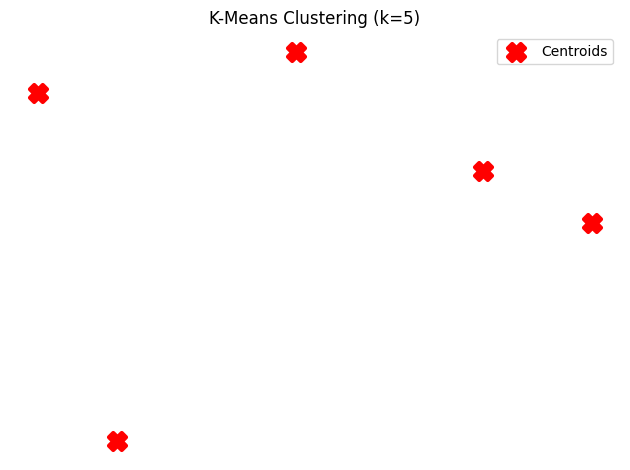

Cluster Centers:
 [[ 2.04588928  4.13924851]
 [-6.91459562 -6.82220969]
 [-8.85721659  7.3281411 ]
 [-2.53116173  9.01582781]
 [ 4.7182956   2.02476404]]


In [4]:
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=150, marker='X', linewidths=3, label='Centroids')

plt.title(f"K-Means Clustering (k={k})")
plt.legend()
plt.axis('off')
plt.tight_layout()
plt.show()

print("Cluster Centers:\n", centers)

In [5]:
y_pred

array([0, 3, 4, ..., 1, 4, 0], shape=(2000,), dtype=int32)

In [6]:
y_pred is kmeans.labels_

True

In [7]:
import numpy as np
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([0, 4, 0, 0], dtype=int32)

In [8]:
kmeans.transform(X_new)

array([[ 2.96007553, 11.20905957, 10.33631333,  7.4584596 ,  4.71836059],
       [ 2.34237303, 13.27142005, 12.99933355,  8.93395713,  1.71847404],
       [ 5.17289917, 10.57354539,  7.28284227,  6.0340694 ,  7.77966401],
       [ 5.30548153, 10.11076913,  7.59064771,  6.53267337,  7.73291253]])

In [9]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)

In [10]:
kmeans.fit(X)

print("Inertia:", kmeans.inertia_)

Inertia: 12630.93593960227


In [11]:
kmeans.score(X)

-12630.93593960227

In [12]:
from sklearn.cluster import MiniBatchKMeans
minibatch_kmeans = MiniBatchKMeans(n_clusters=5)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


In [13]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

0.6178435956745626

In [14]:
import os
from matplotlib.image import imread
import urllib.request

url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/images/unsupervised_learning/ladybug.png"
urllib.request.urlretrieve(url, "ladybug.png")

image = imread("ladybug.png")
print("Original image shape:", image.shape)


Original image shape: (533, 800, 3)


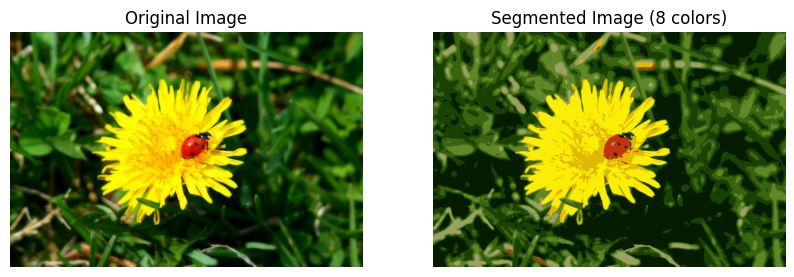

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = image.reshape(-1, 3)

k = 8
kmeans = KMeans(n_clusters=k, random_state=42).fit(X)

segmented_img = kmeans.cluster_centers_[kmeans.labels_]

segmented_img = segmented_img.reshape(image.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Segmented Image ({k} colors)")
plt.imshow(segmented_img)
plt.axis('off')

plt.show()

In [16]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_digits, y_digits = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, random_state=42)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)

print("Baseline Accuracy:", log_reg.score(X_test, y_test))

Baseline Accuracy: 0.9733333333333334


In [17]:
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, random_state=42)),
    ("scaler", StandardScaler()),  
    ("log_reg", LogisticRegression(max_iter=5000, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Pipeline Accuracy (Scaled):", pipeline.score(X_test, y_test))

Pipeline Accuracy (Scaled): 0.9711111111111111


In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("kmeans", KMeans(random_state=42)),
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=5000, random_state=42))
])

param_grid = dict(kmeans__n_clusters=range(50, 100, 10))

grid_clf = GridSearchCV(pipeline, param_grid, cv=3, verbose=2)
grid_clf.fit(X_train, y_train)

print("Best k found:", grid_clf.best_params_)
print("Best Accuracy:", grid_clf.score(X_test, y_test))

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ..............................kmeans__n_clusters=50; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=50; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.2s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=60; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=70; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=80; total time=   0.3s
[CV] END ..............................kmeans__n_clusters=80; total time=   0.3s
[CV] END ..............................kmeans__n_

In [19]:
import numpy as np

k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)

representative_digit_idx = np.argmin(X_digits_dist, axis=0)

X_representative_digits = X_train[representative_digit_idx]

In [20]:
y_representative_digits = y_train[representative_digit_idx]

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=5000, random_state=42)
log_reg.fit(X_representative_digits, y_representative_digits)

print("Accuracy (50 representative samples):", log_reg.score(X_test, y_test))

Accuracy (50 representative samples): 0.9133333333333333


In [21]:
y_train_propagated = np.empty(len(X_train), dtype=np.int32)
for i in range(k):
    y_train_propagated[kmeans.labels_==i] = y_representative_digits[i]

log_reg_prop = LogisticRegression(max_iter=5000, random_state=42)
log_reg_prop.fit(X_train, y_train_propagated)
print("Accuracy (Fully Propagated):", log_reg_prop.score(X_test, y_test))

Accuracy (Fully Propagated): 0.92


In [22]:
percentile_closest = 20
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [23]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import numpy as np

X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.05
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [24]:
dbscan.labels_

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5,  2,  3,  0,  2,  2,  2,  4,
        2,  2,  4,  0,  5,  1,  0,  5,  5,  3,  2,  2,  2,  4,  5,  0,  6,
        1, -1,  0,  0,  2,  3, -1,  3,  4, -1,  4,  4,  2,  0,  6,  2,  0,
        2,  4,  0,  3,  3,  0,  3,  5,  2, -1,  3,  0,  5,  0,  0,  0,  2,
        3,  0,  3,  6,  0,  2,  4,  4,  0,  3,  0,  4,  0,  3, -1,  3,  4,
        0, -1,  2,  2,  4,  1,  6,  0,  5,  2,  6,  2,  3,  3, -1,  2, -1,
        2,  4,  0,  0,  0,  2,  5,  2,  0,  2, -1,  2,  3,  1,  5,  2,  0,
        4,  2,  1,  2,  4,  4,  0,  0,  6,  2,  2,  0,  2, -1,  2,  0,  3,
        3,  5, -1,  3,  3,  5,  2,  4,  2,  2,  2,  4,  2,  4,  0, -1,  2,
        1,  2,  6,  4,  2,  3,  2, -1,  2,  0,  0,  2,  0,  4,  0,  4,  4,
        1,  6,  3,  2,  6,  1,  4,  4,  2,  0,  6,  0,  1,  0,  2,  5,  1,
        1,  2,  2,  2,  2,  0,  5,  5,  1,  4,  5,  0,  3,  3,  0,  0,  0,
        2,  0,  5,  2, -1,  2,  3,  5,  2,  2,  0,  4,  0,  4,  2,  2,  4,
        2,  2,  3,  2,  3

In [26]:
len(dbscan.core_sample_indices_)

808

In [27]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(808, 2))

In [28]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])

knn.predict(X_new)

array([6, 0, 3, 2])

In [29]:
knn.predict_proba(X_new)

array([[0.24, 0.  , 0.  , 0.  , 0.  , 0.  , 0.76],
       [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 0.3 , 0.7 , 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  ]])

In [30]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)

y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]

y_pred[y_dist > 0.2] = -1

y_pred.ravel()

array([-1,  0,  3, -1])

In [31]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",10
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [32]:
gm.weights_

array([0.58665595, 0.20291052, 0.21043353])

In [33]:
gm.means_

array([[ 0.49067581,  0.2579044 ],
       [-0.74886394,  0.5549146 ],
       [ 1.72666283, -0.07241745]])

In [34]:
gm.covariances_

array([[[ 0.1633683 , -0.09679743],
        [-0.09679743,  0.28719319]],

       [[ 0.05311309,  0.06174985],
        [ 0.06174985,  0.08971553]],

       [[ 0.06282163,  0.06680095],
        [ 0.06680095,  0.08831191]]])

In [35]:
gm.predict(X)

array([0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 2, 0, 2, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 2, 2, 2, 1, 0, 0, 1, 1, 0, 0, 0, 2, 0, 1, 0, 1, 2,
       1, 0, 2, 0, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 2, 0, 0, 0, 0, 2, 0, 2,
       0, 2, 2, 2, 0, 1, 0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 0, 1, 2, 0, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 0, 2, 1, 0, 0, 2, 1,
       2, 1, 1, 0, 0, 2, 0, 0, 0, 0, 2, 0, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1,
       0, 0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 1, 2, 0, 0, 2, 2, 0, 1, 0, 0, 2, 0,
       1, 0, 2, 0, 2, 0, 0, 1, 2, 0, 1, 2, 1, 0, 0, 0, 0, 2, 0, 1, 0, 0,
       0, 2, 1, 0, 1, 0, 0, 0, 0, 2, 0, 2, 1, 1, 0, 2, 2, 0, 0, 1, 0, 0,
       1, 2, 2, 1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 0,
       1, 1, 0, 2, 2, 0, 0, 1, 1, 1, 2, 1, 0, 0, 0,

In [36]:
gm.predict_proba(X)

array([[1.00000000e+000, 3.64951782e-014, 3.00738850e-079],
       [9.99452341e-001, 1.60299628e-122, 5.47658976e-004],
       [9.99998163e-001, 8.31445845e-110, 1.83673723e-006],
       ...,
       [1.56339547e-002, 5.58529742e-187, 9.84366045e-001],
       [3.23032437e-004, 9.99676968e-001, 4.00806204e-157],
       [1.00000000e+000, 1.83929503e-046, 3.86023192e-038]],
      shape=(1000, 3))

In [41]:
X_new, y_new = gm.sample(6)
X_new

array([[ 0.75311295,  0.83224471],
       [ 0.48802486,  0.10075663],
       [ 0.27201943,  1.18827386],
       [ 0.78027722,  0.10427621],
       [-0.61544416,  0.66843781],
       [-0.67385613,  0.38762816]])

In [40]:
y_new

array([0, 0, 0, 0, 1, 1])

In [42]:
gm.score_samples(X)

array([-1.58493046e+00, -1.85152755e+00, -1.58315650e+00, -1.90369951e+00,
       -2.30657201e-01, -1.35004833e+00, -1.58796894e+00, -1.57793817e+00,
       -3.60832648e-01, -1.79854552e+00, -1.79842049e+00, -1.67554563e+00,
       -1.44635406e+00, -4.85981937e-01, -8.65932133e-01,  9.73264815e-03,
       -2.17833947e+00, -7.22318802e-01, -1.99610252e+00, -9.05574514e-01,
       -1.75480071e+00, -1.76337699e+00, -1.14690944e-01, -1.58731320e+00,
       -1.53324414e+00, -1.74849220e+00, -1.66473461e+00, -1.24215398e+00,
       -3.36756602e-01, -5.62649259e-01, -5.13400485e-01, -1.43757187e+00,
       -1.81779190e+00, -1.99769200e+00,  1.13898739e-02, -1.95671357e+00,
       -1.58206750e+00, -1.27573646e+00, -2.96564395e-01, -1.57837509e+00,
       -1.18811165e+00, -1.66965920e+00, -1.05567046e+00, -1.20620316e+00,
       -1.50183800e+00, -2.10412814e+00, -1.69653555e+00, -1.56653560e+00,
       -3.12996755e-01, -5.49281548e-01, -1.81285858e+00, -9.13057956e-01,
       -1.95307027e+00, -